In [ ]:
!pip install catboost

In [1]:
# Import necessary libraries
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# Display the first few rows
print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [3]:
# Drop irrelevant columns
df.drop(['customer_id'], axis=1, inplace=True)

# Identify categorical features
cat_features = ['country', 'gender']

# Encode categorical features as category dtype
for col in cat_features:
    df[col] = df[col].astype('category')

# Define features and target variable
X = df.drop('churn', axis=1)
y = df['churn']

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize CatBoostClassifier
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.8277792	best: 0.8277792 (0)	total: 66.7ms	remaining: 33.3s
100:	test: 0.8733418	best: 0.8735932 (98)	total: 327ms	remaining: 1.29s
200:	test: 0.8745340	best: 0.8752142 (124)	total: 559ms	remaining: 832ms
300:	test: 0.8717932	best: 0.8752142 (124)	total: 798ms	remaining: 527ms
400:	test: 0.8682920	best: 0.8752142 (124)	total: 1.04s	remaining: 257ms
499:	test: 0.8650191	best: 0.8752142 (124)	total: 1.28s	remaining: 0us

bestTest = 0.8752141972
bestIteration = 124

Shrink model to first 125 iterations.


In [7]:
# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.81      0.46      0.59       407

    accuracy                           0.87      2000
   macro avg       0.85      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



Confusion Matrix:


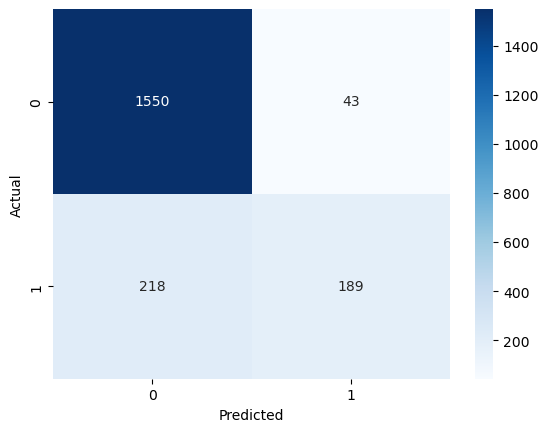

In [9]:
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [11]:
print(f"AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

AUC Score: 0.8752


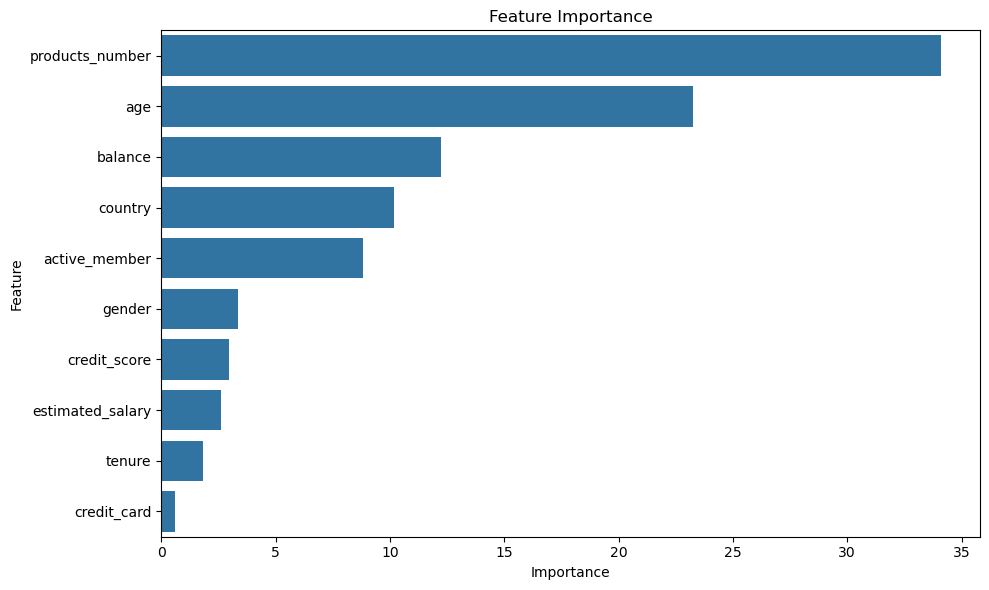

In [13]:
# Feature Importance
feature_importances = model.get_feature_importance()
feature_names = X.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()